
# Car Price Prediction Project (Regression)

Dataset: **car.csv**

Steps included:
- Data Loading
- Data Preprocessing
- EDA
- Model Training (Linear Regression + Random Forest)
- Model Evaluation (MAE, MSE, R²)
- Best Model Selection
- Save Model (.pkl)


In [ ]:
! pip install flask

In [ ]:
! pip install seaborn matplotlib scikit-learn pandas numpy streamlit

In [3]:

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle


In [4]:

# Load dataset

data = pd.read_csv("car.csv")
data.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:

# Dataset info

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:

# Missing values check

data.isnull().sum()


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [7]:

# Drop unnecessary column

data = data.drop("name", axis=1)
data.head()


,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [8]:

# Encoding categorical columns

le = LabelEncoder()

data['fuel'] = le.fit_transform(data['fuel'])
data['seller_type'] = le.fit_transform(data['seller_type'])
data['transmission'] = le.fit_transform(data['transmission'])
data['owner'] = le.fit_transform(data['owner'])

data.head()


,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,2007,60000,70000,4,1,1,0
1,2007,135000,50000,4,1,1,0
2,2012,600000,100000,1,1,1,0
3,2017,250000,46000,4,1,1,0
4,2014,450000,141000,1,1,1,2


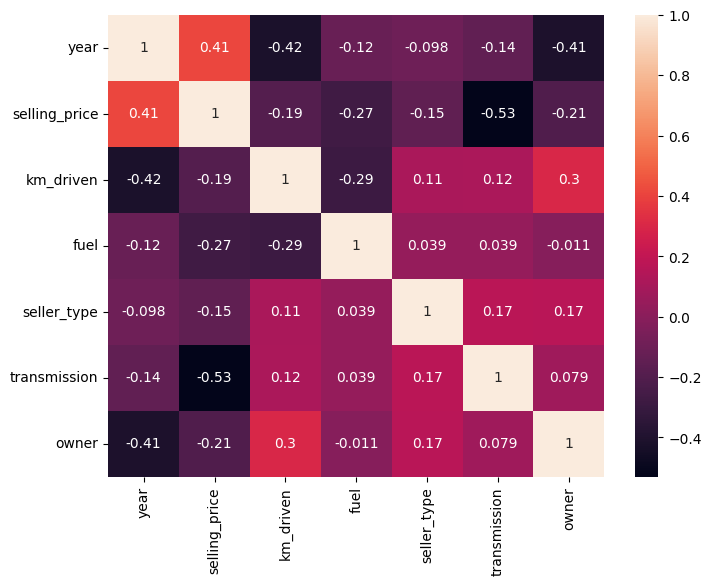

In [9]:

# Correlation heatmap (EDA)

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.show()


In [10]:

# Define X and y

X = data.drop("selling_price", axis=1)
y = data["selling_price"]


In [11]:

# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:

# Linear Regression model

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


In [13]:

# Random Forest model

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [14]:

# Linear Regression Evaluation

print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))


Linear Regression Results
MAE: 222188.9426151668
MSE: 184963450105.7347
R2 Score: 0.3939008529340028


In [15]:

# Random Forest Evaluation

print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))


Random Forest Results
MAE: 168444.41658869584
MSE: 152679724201.06885
R2 Score: 0.4996900708781147


In [16]:

# Save best model (Random Forest)

pickle.dump(rf, open("car_price_model.pkl", "wb"))

print("Model saved successfully as car_price_model.pkl")


Model saved successfully as car_price_model.pkl
